# Unit07 Example 01 — Van der Waals 狀態方程式

本 Notebook 以 **Van der Waals (VdW) 狀態方程式**為主題，示範單變數非線性方程式的完整求解流程。

## 目標

- 將 VdW 方程式轉化為 $f(V) = 0$ 並分析根的物理意義
- 透過圖形法（ $f(V)$ 圖、$P$-$V$ 等溫線）判斷根的數量與位置
- 使用 Bisection 法和 Newton-Raphson 法自行實作求根
- 比較 `root_scalar()` 多種方法（brentq、newton、secant、bisect）
- 探討工況對根數的影響：三根（兩相區）vs 單根（超臨界）
- 比較理想氣體與 VdW 方程式的計算結果差異


## 0. 環境設定

In [1]:
from pathlib import Path

# ========================================
# 路徑設定
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_01'

NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
FIG_DIR = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_01\figs


## 1. 載入相關套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, root_scalar
import warnings

plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件載入完成")

✓ 套件載入完成


## 2. 問題描述與參數設定

Van der Waals 狀態方程式：

$$
P = \frac{RT}{V - b} - \frac{a}{V^2}
$$

整理成 $f(V) = 0$ 的形式：

$$
f(V) = PV^3 - (Pb + RT)V^2 + aV - ab = 0
$$

**CO₂ van der Waals 參數（SI 單位）：**

| 參數 | 數值 | 單位 |
|------|------|------|
| $a$  | 0.3658 | Pa·m⁶/mol² |
| $b$  | 4.267×10⁻⁵ | m³/mol |
| $T_c$ | 304.2 | K |
| $P_c$ | 73.8 | bar |

**測試工況：**

| 案例 | T (K) | P (bar) | 預期根數 | 說明 |
|------|-------|---------|--------|------|
| A    | 250   | 30      | 3      | $T < T_c$，兩相區，有汽液共存 |
| B    | 350   | 100     | 1      | $T > T_c$，超臨界狀態 |

In [3]:
# ── 通用常數 ──────────────────────────────────────────────
R = 8.314          # J/(mol·K)

# ── CO2 VdW 參數 ──────────────────────────────────────────
a_co2 = 0.3658     # Pa·m6/mol2
b_co2 = 4.267e-5   # m3/mol
Tc_co2 = 304.2     # K
Pc_co2 = 73.8e5    # Pa  (73.8 bar)

# ── 多氣體比較用資料 ──────────────────────────────────────
gases = {
    "CO2": {"a": 0.3658,  "b": 4.267e-5},
    "N2" : {"a": 0.1370,  "b": 3.870e-5},
    "CH4": {"a": 0.2283,  "b": 4.278e-5},
}

# ── 輔助函式 ──────────────────────────────────────────────
def vdw_eq(V, T, P, a, b):
    """VdW f(V) = P*V^3 - (P*b+R*T)*V^2 + a*V - a*b"""
    return P*V**3 - (P*b + R*T)*V**2 + a*V - a*b

def vdw_deriv(V, T, P, a, b):
    """df/dV = 3P*V^2 - 2(P*b+R*T)*V + a"""
    return 3*P*V**2 - 2*(P*b + R*T)*V + a

def check_stability(V, T, a, b):
    """穩定性檢查：(dP/dV)_T < 0 表示穩定"""
    dPdV = -R*T/(V - b)**2 + 2*a/V**3
    return "stable" if dPdV < 0 else "UNSTABLE"

# ── 工況 ──────────────────────────────────────────────────
cases = {
    "A": {"T": 250.0, "P": 30.0e5},   # 兩相區 (T < Tc)
    "B": {"T": 350.0, "P": 100.0e5},  # 超臨界 (T > Tc)
}

print("="*52)
print(f"  CO2 VdW Parameters")
print(f"  a  = {a_co2:.4f} Pa·m6/mol2")
print(f"  b  = {b_co2:.3e} m3/mol")
print(f"  Tc = {Tc_co2:.1f} K")
print(f"  Pc = {Pc_co2/1e5:.1f} bar")
print("="*52)
for _lbl, _cnd in cases.items():
    print(f"  Case {_lbl}: T={_cnd['T']:.0f} K, P={_cnd['P']/1e5:.0f} bar")
print("="*52)

  CO2 VdW Parameters
  a  = 0.3658 Pa·m6/mol2
  b  = 4.267e-05 m3/mol
  Tc = 304.2 K
  Pc = 73.8 bar
  Case A: T=250 K, P=30 bar
  Case B: T=350 K, P=100 bar


## 2. 圖形分析

### 2.1 $f(V)$ 函數圖

繪製 Case A（T=250 K, P=30 bar）的 $f(V)$ 曲線，圖中三個過零點即為方程式的三個根：
- 液相根 $V_L$（最小值，左側）
- 不穩定中間根 $V_M$
- 氣相根 $V_G$（最大值，右側）


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_01\figs\fig_01_fV_plot.png


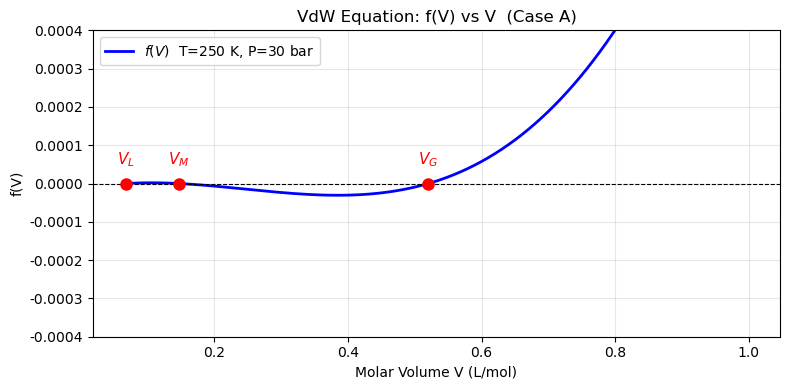

In [4]:
T_a = cases["A"]["T"]
P_a = cases["A"]["P"]

V_arr = np.linspace(6.5e-5, 1.0e-3, 2000)   # V > b = 4.267e-5 m3/mol
f_arr = vdw_eq(V_arr, T_a, P_a, a_co2, b_co2)

# 先用 brentq 找出三根位置，用於圖形標記
_bracks_plot = []
_V_scan = np.linspace(6.5e-5, 1.0e-3, 5000)
_f_scan = vdw_eq(_V_scan, T_a, P_a, a_co2, b_co2)
for _i in range(len(_f_scan) - 1):
    if _f_scan[_i] * _f_scan[_i+1] < 0:
        _bracks_plot.append((_V_scan[_i], _V_scan[_i+1]))
_roots_plot = [brentq(vdw_eq, va, vb, args=(T_a, P_a, a_co2, b_co2)) for va, vb in _bracks_plot]
_root_annots = ["$V_L$", "$V_M$", "$V_G$"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(V_arr * 1e3, f_arr, "b-", lw=2, label=f"$f(V)$  T={T_a:.0f} K, P={P_a/1e5:.0f} bar")
ax.axhline(0, color="k", lw=0.8, ls="--")

# 標記三個根
for _vr, _ann in zip(_roots_plot, _root_annots):
    ax.plot(_vr * 1e3, 0, "ro", ms=8, zorder=5)
    ax.annotate(_ann, xy=(_vr * 1e3, 0),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=11, color="red")

ax.set_xlabel("Molar Volume V (L/mol)")
ax.set_ylabel("f(V)")
ax.set_title("VdW Equation: f(V) vs V  (Case A)")
ax.set_ylim(-4e-4, 4e-4)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'fig_01_fV_plot.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ 圖檔已儲存: {fig_path}")

plt.show()

### 2.2 $P$-$V$ 等溫線

繪製多條等溫線，觀察 VdW 「Maxwell loop」現象：當 $T < T_c$ 時，$P$-$V$ 曲線出現 S 型迴路，代表物理上不穩定的液汽共存區域。


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_01\figs\fig_02_PV_isotherms.png
VdW Critical Point: Tc=304.2 K, Vc=0.1280 L/mol, Pc=74.41 bar


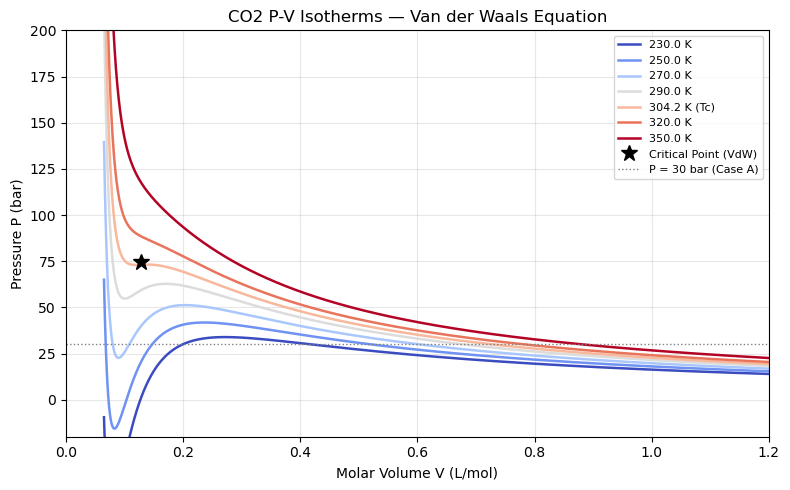

In [5]:
T_list = [230, 250, 270, 290, 304.2, 320, 350]   # [K]
colors  = plt.cm.coolwarm(np.linspace(0, 1, len(T_list)))

V_iso = np.linspace(6.5e-5, 1.2e-3, 2000)  # m3/mol

fig, ax = plt.subplots(figsize=(8, 5))

for T_iso, col in zip(T_list, colors):
    lbl = f"{T_iso:.1f} K" + (" (Tc)" if T_iso == 304.2 else "")
    P_iso = R * T_iso / (V_iso - b_co2) - a_co2 / V_iso**2
    ax.plot(V_iso * 1e3, P_iso / 1e5, color=col, lw=1.8, label=lbl)

# 標記臨界點
Vc_co2 = 3 * b_co2           # VdW: Vc = 3b
Pc_vdw = a_co2 / (27 * b_co2**2)
ax.plot(Vc_co2 * 1e3, Pc_vdw / 1e5, "k*", ms=12, zorder=5, label="Critical Point (VdW)")

ax.axhline(30, color="gray", ls=":", lw=1, label="P = 30 bar (Case A)")
ax.set_xlim(0, 1.2)
ax.set_ylim(-20, 200)
ax.set_xlabel("Molar Volume V (L/mol)")
ax.set_ylabel("Pressure P (bar)")
ax.set_title("CO2 P-V Isotherms — Van der Waals Equation")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'fig_02_PV_isotherms.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ 圖檔已儲存: {fig_path}")
print(f"VdW Critical Point: Tc={Tc_co2} K, Vc={Vc_co2*1e3:.4f} L/mol, Pc={Pc_vdw/1e5:.2f} bar")

plt.show()

## 3. 數值求解

### 3.1 符號掃描法尋找根所在區間

以等間距的樣本點掃描 $f(V)$，當相鄰兩點乘積為負時，代表該區間存在根（符號改變），從而確定 Bracketing 求根的初始區間。


In [6]:
def sign_scan(T, P, a, b, n_pts=5000):
    """掃描 f(V) 符號改變，回傳 [(Va, Vb), ...] 的 bracket 列表"""
    V_scan = np.linspace(1.05 * b, 2e-3, n_pts)
    f_scan = vdw_eq(V_scan, T, P, a, b)
    brackets = []
    for i in range(len(f_scan) - 1):
        if f_scan[i] * f_scan[i+1] < 0:
            brackets.append((V_scan[i], V_scan[i+1]))
    return brackets

# Case A ──────────────────────────────────────────────────
T_a, P_a = cases["A"]["T"], cases["A"]["P"]
brackets_A = sign_scan(T_a, P_a, a_co2, b_co2)

print("Case A — Sign-change brackets found:")
for i, (va, vb) in enumerate(brackets_A):
    fa = vdw_eq(va, T_a, P_a, a_co2, b_co2)
    fb = vdw_eq(vb, T_a, P_a, a_co2, b_co2)
    print(f"  Bracket {i+1}: V in [{va*1e3:.5f}, {vb*1e3:.5f}] L/mol  "
          f"  f(Va)={fa:.3e}, f(Vb)={fb:.3e}")

# Case B ──────────────────────────────────────────────────
T_b, P_b = cases["B"]["T"], cases["B"]["P"]
brackets_B = sign_scan(T_b, P_b, a_co2, b_co2)

print(f"\nCase B — Sign-change brackets found: {len(brackets_B)}")
for i, (va, vb) in enumerate(brackets_B):
    print(f"  Bracket {i+1}: V in [{va*1e3:.5f}, {vb*1e3:.5f}] L/mol")


Case A — Sign-change brackets found:
  Bracket 1: V in [0.06788, 0.06827] L/mol    f(Va)=-6.856e-09, f(Vb)=3.503e-08
  Bracket 2: V in [0.14689, 0.14728] L/mol    f(Va)=2.315e-08, f(Vb)=-1.149e-08
  Bracket 3: V in [0.52040, 0.52079] L/mol    f(Va)=-5.522e-09, f(Vb)=1.930e-07

Case B — Sign-change brackets found: 1
  Bracket 1: V in [0.17622, 0.17661] L/mol


### 3.2 用 brentq 求出所有根 — Case A（三根）與 Case B（單根）

對每個 bracket 呼叫 `brentq`，並計算壓縮因子 $Z = PV / (RT)$ 與穩定性判斷。

$$
Z = \frac{PV}{RT}
$$

穩定性條件（等溫）：

$$
\left(\frac{\partial P}{\partial V}\right)_T = \frac{-RT}{(V-b)^2} + \frac{2a}{V^3} < 0
$$


In [7]:
def solve_vdw_roots(T, P, a, b, label=""):
    """使用 sign_scan + brentq 求 VdW 方程式所有根"""
    brackets = sign_scan(T, P, a, b)
    roots = []
    for va, vb in brackets:
        V_root = brentq(vdw_eq, va, vb, args=(T, P, a, b), xtol=1e-14)
        Z = P * V_root / (R * T)
        stab = check_stability(V_root, T, a, b)
        roots.append({"V": V_root, "Z": Z, "stability": stab})
    return roots

# ── Case A ────────────────────────────────────────────────
roots_A = solve_vdw_roots(T_a, P_a, a_co2, b_co2)
root_labels = ["Liquid (VL)", "Unstable (VM)", "Gas (VG)"]

print(f"Case A  T={T_a:.0f} K  P={P_a/1e5:.0f} bar")
print(f"{'Root':<18} {'V (L/mol)':>12} {'Z':>8} {'Stability':>12}")
print("-" * 54)
for i, r in enumerate(roots_A):
    lbl = root_labels[i] if i < len(root_labels) else f"Root {i+1}"
    print(f"{lbl:<18} {r['V']*1e3:>12.5f} {r['Z']:>8.4f} {r['stability']:>12}")

# ── Case B ────────────────────────────────────────────────
roots_B = solve_vdw_roots(T_b, P_b, a_co2, b_co2)
print(f"\nCase B  T={T_b:.0f} K  P={P_b/1e5:.0f} bar")
print(f"{'Root':<18} {'V (L/mol)':>12} {'Z':>8} {'Stability':>12}")
print("-" * 54)
for i, r in enumerate(roots_B):
    print(f"{'Supercritical':<18} {r['V']*1e3:>12.5f} {r['Z']:>8.4f} {r['stability']:>12}")


Case A  T=250 K  P=30 bar
Root                  V (L/mol)        Z    Stability
------------------------------------------------------
Liquid (VL)             0.06794   0.0981       stable
Unstable (VM)           0.14715   0.2124     UNSTABLE
Gas (VG)                0.52041   0.7511       stable

Case B  T=350 K  P=100 bar
Root                  V (L/mol)        Z    Stability
------------------------------------------------------
Supercritical           0.17653   0.6067       stable


### 3.3 多種方法比較 — `root_scalar`

使用 `scipy.optimize.root_scalar` 以四種方法求 Case A 的氣相根 $V_G$，比較迭代次數與結果。

| 方法 | 類型 | 需要導數？ | 備註 |
|------|------|-----------|------|
| `brentq` | Bracketing | 否 | 最可靠，兼用二分與固定點 |
| `bisect`  | Bracketing | 否 | 純二分，收斂較慢 |
| `newton`  | Open | 是 | 需提供初始估計與導數，收斂最快 |
| `secant`  | Open | 否（近似） | 需兩個初始點，近似 Newton 法 |


In [8]:
# 以 Case A 的氣相根 (第3個 bracket) 進行四種方法比較
va_gas, vb_gas = brackets_A[-1]          # 最右側 bracket
V0_gas = R * T_a / P_a                   # 理想氣體初始估計

methods_config = [
    {"method": "brentq",  "bracket": [va_gas, vb_gas]},
    {"method": "bisect",  "bracket": [va_gas, vb_gas]},
    {"method": "newton",  "x0": V0_gas,  "fprime": lambda V: vdw_deriv(V, T_a, P_a, a_co2, b_co2)},
    {"method": "secant",  "x0": V0_gas,  "x1": V0_gas * 0.9},
]

print(f"Case A — Gas root comparison (T={T_a:.0f} K, P={P_a/1e5:.0f} bar)")
print(f"  Ideal gas estimate: V0 = {V0_gas*1e3:.5f} L/mol")
print()
print(f"{'Method':<10} {'V_root (L/mol)':>16} {'Z':>8} {'Iterations':>12} {'Converged':>10}")
print("-" * 60)

for cfg in methods_config:
    kw = {k: v for k, v in cfg.items() if k != "method"}
    sol = root_scalar(
        lambda V: vdw_eq(V, T_a, P_a, a_co2, b_co2),
        **kw,
        method=cfg["method"],
        xtol=1e-12
    )
    Z = P_a * sol.root / (R * T_a)
    iters = sol.iterations if hasattr(sol, "iterations") else "N/A"
    print(f"{cfg['method']:<10} {sol.root*1e3:>16.6f} {Z:>8.5f} {str(iters):>12} {str(sol.converged):>10}")


Case A — Gas root comparison (T=250 K, P=30 bar)
  Ideal gas estimate: V0 = 0.69283 L/mol

Method       V_root (L/mol)        Z   Iterations  Converged
------------------------------------------------------------
brentq             0.520413  0.75114            4       True
bisect             0.520413  0.75114           19       True
newton             0.520413  0.75114            6       True
secant             0.520413  0.75114            8       True


## 4. 與理想氣體的比較

以壓縮因子 $Z = PV/(RT)$ 衡量真實氣體與理想氣體的偏差（理想氣體 $Z=1$）。  
對 CO₂、N₂、CH₄ 三種氣體在 T=300 K、P=30 bar 下進行比較。


In [9]:
T_cmp = 300.0    # K
P_cmp = 30.0e5   # Pa

V_ideal = R * T_cmp / P_cmp
Z_ideal = 1.0

print(f"Condition: T={T_cmp:.0f} K, P={P_cmp/1e5:.0f} bar")
print(f"Ideal Gas: V = {V_ideal*1e3:.5f} L/mol, Z = {Z_ideal:.4f}")
print()
print(f"{'Gas':<8} {'V_vdw (L/mol)':>16} {'Z_vdw':>8} {'Z-1 (%)':>10} {'Stability':>12}")
print("-" * 58)

for gas_name, params in gases.items():
    a_g, b_g = params["a"], params["b"]
    bracks = sign_scan(T_cmp, P_cmp, a_g, b_g)
    if len(bracks) == 0:
        print(f"{gas_name:<8} {'No root found':>16}")
        continue
    # 取最大根（氣相）
    va_g, vb_g = bracks[-1]
    V_g = brentq(vdw_eq, va_g, vb_g, args=(T_cmp, P_cmp, a_g, b_g), xtol=1e-14)
    Z_g = P_cmp * V_g / (R * T_cmp)
    stab = check_stability(V_g, T_cmp, a_g, b_g)
    dev = (Z_g - 1.0) * 100
    print(f"{gas_name:<8} {V_g*1e3:>16.5f} {Z_g:>8.4f} {dev:>10.2f} {stab:>12}")


Condition: T=300 K, P=30 bar
Ideal Gas: V = 0.83140 L/mol, Z = 1.0000

Gas         V_vdw (L/mol)    Z_vdw    Z-1 (%)    Stability
----------------------------------------------------------
CO2               0.71337   0.8580     -14.20       stable
N2                0.81684   0.9825      -1.75       stable
CH4               0.78221   0.9408      -5.92       stable


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_01\figs\fig_03_Z_vs_P.png


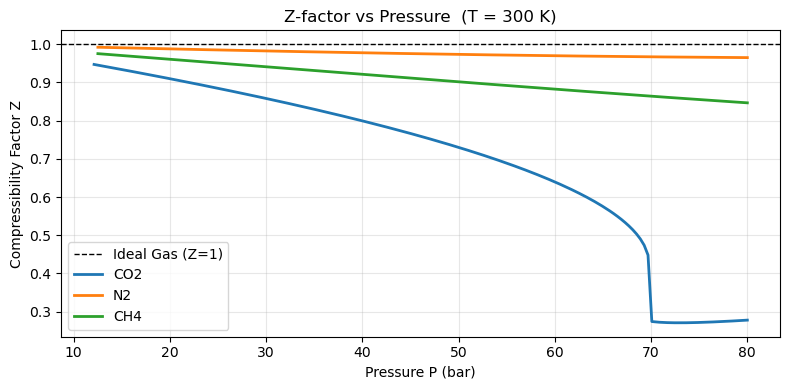

In [10]:
# 繪製 Z vs P 曲線（T=300K，P=1~80 bar）
P_range = np.linspace(1e5, 80e5, 200)   # Pa
T_z = 300.0

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(1.0, color="k", ls="--", lw=1, label="Ideal Gas (Z=1)")

colors_g = ["tab:blue", "tab:orange", "tab:green"]
for (gas_name, params), col in zip(gases.items(), colors_g):
    a_g, b_g = params["a"], params["b"]
    Z_arr = []
    for P_pt in P_range:
        bracks_pt = sign_scan(T_z, P_pt, a_g, b_g)
        if bracks_pt:
            va_pt, vb_pt = bracks_pt[-1]
            V_pt = brentq(vdw_eq, va_pt, vb_pt, args=(T_z, P_pt, a_g, b_g), xtol=1e-14)
            Z_arr.append(P_pt * V_pt / (R * T_z))
        else:
            Z_arr.append(np.nan)
    ax.plot(P_range / 1e5, Z_arr, color=col, lw=2, label=gas_name)

ax.set_xlabel("Pressure P (bar)")
ax.set_ylabel("Compressibility Factor Z")
ax.set_title("Z-factor vs Pressure  (T = 300 K)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 儲存圖檔
fig_path = FIG_DIR / 'fig_03_Z_vs_P.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ 圖檔已儲存: {fig_path}")

plt.show()

## 5. 結果驗證

將求得的根代回 $f(V)$ 計算殘差（residual），以驗證求根精度。同時輸出所有案例的完整結果摘要表。


In [11]:
root_type_names = {0: "Liquid VL", 1: "Unstable VM", 2: "Gas VG"}

print("=" * 70)
print(f" Case A  T={T_a:.0f} K  P={P_a/1e5:.0f} bar  (Two-phase region, T < Tc)")
print(f" {'Type':<16} {'V (L/mol)':>12} {'Z':>8} {'|f(V)|':>14} {'Stability':>12}")
print("-" * 70)
for i, r in enumerate(roots_A):
    V_r = r["V"]
    residual = abs(vdw_eq(V_r, T_a, P_a, a_co2, b_co2))
    lbl = root_type_names.get(i, f"Root {i+1}")
    print(f" {lbl:<16} {V_r*1e3:>12.5f} {r['Z']:>8.4f} {residual:>14.3e} {r['stability']:>12}")

print()
print("=" * 70)
print(f" Case B  T={T_b:.0f} K  P={P_b/1e5:.0f} bar  (Supercritical, T > Tc)")
print(f" {'Type':<16} {'V (L/mol)':>12} {'Z':>8} {'|f(V)|':>14} {'Stability':>12}")
print("-" * 70)
for i, r in enumerate(roots_B):
    V_r = r["V"]
    residual = abs(vdw_eq(V_r, T_b, P_b, a_co2, b_co2))
    print(f" {'Supercritical':<16} {V_r*1e3:>12.5f} {r['Z']:>8.4f} {residual:>14.3e} {r['stability']:>12}")
print("=" * 70)


 Case A  T=250 K  P=30 bar  (Two-phase region, T < Tc)
 Type                V (L/mol)        Z         |f(V)|    Stability
----------------------------------------------------------------------
 Liquid VL             0.06794   0.0981      3.388e-21       stable
 Unstable VM           0.14715   0.2124      6.776e-21     UNSTABLE
 Gas VG                0.52041   0.7511      1.830e-18       stable

 Case B  T=350 K  P=100 bar  (Supercritical, T > Tc)
 Type                V (L/mol)        Z         |f(V)|    Stability
----------------------------------------------------------------------
 Supercritical         0.17653   0.6067      0.000e+00       stable


## 6. 總結

本範例完整示範了以 Van der Waals 狀態方程式為例的單變數非線性求根流程：

1. **問題轉化**：將 VdW 方程式整理成 $f(V) = PV^3 - (Pb+RT)V^2 + aV - ab = 0$
2. **圖形分析**：先畫 $f(V)$ 與 $P$-$V$ 等溫線，確認根的數量與位置
3. **符號掃描**：自動找出所有符號改變的 bracket，再交給 brentq 精確求根
4. **方法比較**：`brentq`、`bisect`（需 bracket）、`newton`（需導數）、`secant` 均收斂至相同根
5. **穩定性**：中間根 $V_M$ 的 $(\partial P / \partial V)_T > 0$，違反熱力學穩定性，為非物理解
6. **氣體比較**：N₂、CH₄、CO₂ 的偏差程度反映分子間作用力強弱（a 值越大偏差越大）

**常見錯誤提醒：**

| 錯誤 | 說明 |
|------|------|
| $V \leq b$ | 分母 $V-b \leq 0$，物理上無意義，掃描範圍須從 $V > b$ 開始 |
| bracket 符號相同 | bracket 內 $f(V)$ 符號未改變，brentq 會 raise `ValueError` |
| 忽略中間根 | 須明確標記為不穩定解，不可作為平衡計算依據 |

---

**課程資訊**
- 課程名稱：化工計算與程式設計（ChemE-3502）
- 課程單元：Unit 07 — 非線性方程式求解
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-19

**課程授權 [CC BY-NC-SA 4.0]**  
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
